# CC3092 – Deep Learning · Proyecto 2
## Detección secuencial de lavado de dinero en transacciones IBM AML

**Curso:** CC3092 – Deep Learning  
**Fecha:** [COMPLETAR]

Este notebook implementa un sistema de detección en dos etapas:

1. **Etapa A:** un LSTM Encoder–Decoder aprende a reconstruir únicamente secuencias normales. El error de reconstrucción se convierte en score de anomalía.
2. **Etapa B:** un clasificador reutiliza el encoder anterior, incorpora atención de producto punto escalado y estima la probabilidad de lavado.

Se incluye una línea base entrenada desde cero, combinación de señales, ablación, interpretabilidad por transacción y exportación de artefactos para el MVP.

> El notebook no contiene métricas inventadas. Debe ejecutarse con los archivos de datos para producir los resultados finales.

## Bloque 0 — Configuración y reproducibilidad

El modo rápido permite verificar el pipeline. Para la ejecución final se debe usar `MODO_RAPIDO = False`. El notebook está preparado para ejecutarse localmente desde la raíz del proyecto y utiliza rutas relativas, de modo que la carpeta completa pueda moverse o compartirse sin modificar rutas absolutas.

In [1]:
from dataclasses import dataclass, asdict
from pathlib import Path
from collections import Counter
import copy, csv, json, math, os, random, time, warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_recall_curve,
    precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

@dataclass
class Config:
    SEED: int = 42
    MODO_RAPIDO: bool = False
    DATA_DIR: str = '.'
    IBM_FILE: str = 'ibm-transactions/HI-Small_Trans.csv'
    PATTERNS_FILE: str = 'ibm-transactions/HI-Small_Patterns.txt'
    PAYSIM_FILE: str = 'paysim/PS_20174392719_1491204439457_log.csv'
    ARTIFACT_DIR: str = 'artifacts_aml'
    MIN_SEQ_LEN: int = 3
    MAX_SEQ_LEN: int = 30
    MAX_WINDOWS_PER_SENDER: int = 20
    MAX_NORMAL_AE: int = 60000
    NORMAL_TO_POSITIVE_B: int = 10
    BATCH_SIZE: int = 256
    HIDDEN_SIZE: int = 64
    LATENT_SIZE: int = 64
    ATTN_SIZE: int = 32
    DROPOUT: float = 0.20
    AE_EPOCHS: int = 8
    HEAD_EPOCHS: int = 3
    FINETUNE_EPOCHS: int = 6
    LR_AE: float = 1e-3
    LR_HEAD: float = 1e-3
    LR_ENCODER: float = 1e-4
    PATIENCE: int = 3
    NUM_WORKERS: int = 0

CFG = Config()
if CFG.MODO_RAPIDO:
    CFG.MAX_NORMAL_AE = 8000
    CFG.AE_EPOCHS = 2
    CFG.HEAD_EPOCHS = 1
    CFG.FINETUNE_EPOCHS = 2

def set_seed(seed=42):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PROJECT_ROOT = Path.cwd().resolve()
DATA_DIR = (PROJECT_ROOT / CFG.DATA_DIR).resolve()
IBM_PATH = DATA_DIR / CFG.IBM_FILE
PATTERNS_PATH = DATA_DIR / CFG.PATTERNS_FILE
PAYSIM_PATH = DATA_DIR / CFG.PAYSIM_FILE
ARTIFACT_DIR = (PROJECT_ROOT / CFG.ARTIFACT_DIR).resolve()
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
T0_GLOBAL = time.time()

print('PyTorch:', torch.__version__)
print('Pandas:', pd.__version__)
print('Dispositivo:', DEVICE)
print('Raíz del proyecto:', PROJECT_ROOT)
print('Archivo IBM:', IBM_PATH)
print('Archivo de patrones:', PATTERNS_PATH)
print('Directorio de artefactos:', ARTIFACT_DIR)
print('Modo rápido:', CFG.MODO_RAPIDO)

PyTorch: 2.14.0+cpu
Pandas: 2.3.3
Dispositivo: cpu
Raíz del proyecto: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2
Archivo IBM: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\ibm-transactions\HI-Small_Trans.csv
Archivo de patrones: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\ibm-transactions\HI-Small_Patterns.txt
Directorio de artefactos: C:\Users\maria\OneDrive\Documents\UVG\Deep Learning\Proyecto 2\artifacts_aml
Modo rápido: False


## Bloque 1 — Decisión de dataset

En nuestra exploración del dataset encontramos que PaySim tiene 6,353,307 remitentes, pero 99 % de ellos posee una sola transacción. Solo 28 remitentes fraudulentos tienen dos transacciones y ninguno tiene tres. Por ello, PaySim no permite aprender comportamiento histórico real por remitente.

IBM AML sí contiene historiales: HI-Small tiene 496,999 remitentes, 3,376 remitentes positivos y percentil 90 de longitud igual a 29. Se selecciona HI-Small porque es menor que LI-Small y ofrece más casos positivos, aunque conserva un desbalance fuerte.

In [3]:
paysim_audit = pd.Series({
    'transacciones': 6_362_620, 'remitentes': 6_353_307,
    'remitentes_longitud_2_o_mas': 9_298,
    'remitentes_longitud_3_o_mas': 15,
    'remitentes_fraudulentos': 8_213,
    'fraudulentos_longitud_2_o_mas': 28,
    'fraudulentos_longitud_3_o_mas': 0
}, name='PaySim — auditoría ejecutada por el grupo')

ibm_comparison = pd.DataFrame({
    'HI-Small': [5_078_345, 5_177, 496_999, 3_376, 0.00679277, 2, 46, 92],
    'LI-Small': [6_924_049, 3_565, 681_283, 2_382, 0.00349634, 2, 46, 92]
}, index=['transacciones','transacciones_positivas','remitentes','remitentes_positivos',
          'tasa_remitentes_positivos','mediana_longitud','p95_longitud','p99_longitud'])

display(paysim_audit.to_frame())
display(ibm_comparison)
assert paysim_audit['fraudulentos_longitud_3_o_mas'] == 0
assert ibm_comparison.loc['remitentes_positivos','HI-Small'] > ibm_comparison.loc['remitentes_positivos','LI-Small']
print('Decisión documentada: HI-Small será el dataset secuencial principal.')

,PaySim — auditoría ejecutada por el grupo
transacciones,6362620
remitentes,6353307
remitentes_longitud_2_o_mas,9298
remitentes_longitud_3_o_mas,15
remitentes_fraudulentos,8213
fraudulentos_longitud_2_o_mas,28
fraudulentos_longitud_3_o_mas,0


,HI-Small,LI-Small
transacciones,5.078345e+06,6.924049e+06
transacciones_positivas,5.177000e+03,3.565000e+03
remitentes,4.969990e+05,6.812830e+05
remitentes_positivos,3.376000e+03,2.382000e+03
tasa_remitentes_positivos,6.792770e-03,3.496340e-03
mediana_longitud,2.000000e+00,2.000000e+00
p95_longitud,4.600000e+01,4.600000e+01
p99_longitud,9.200000e+01,9.200000e+01


Decisión documentada: HI-Small será el dataset secuencial principal.


### Justificación de la selección del dataset

Aunque PaySim se consideró inicialmente como dataset principal, el análisis de su estructura mostró una limitación importante para este proyecto: 6,353,307 de sus remitentes corresponden a una población en la que aproximadamente el 99 % presenta una sola transacción. Entre los 8,213 remitentes asociados con fraude, únicamente 28 poseen al menos dos transacciones y ninguno alcanza tres. Por tanto, construir secuencias históricas por remitente requeriría crear artificialmente una estructura temporal que los datos no contienen.

En contraste, IBM AML HI-Small contiene 5,078,345 transacciones correspondientes a 496,999 remitentes, de los cuales 3,376 presentan al menos una transacción etiquetada como lavado. La mediana del historial es de 2 transacciones, el percentil 90 es 29 y el percentil 95 es 46. Esta estructura permite estudiar comportamiento secuencial real dentro del dataset.

Por esta razón se seleccionó **IBM AML HI-Small como dataset principal para el modelado secuencial**. La decisión no se basa únicamente en tamaño, sino en la compatibilidad entre la estructura de los datos y el objetivo del proyecto: aprender patrones temporales de comportamiento por remitente. PaySim se conserva como referencia comparativa para justificar esta decisión.

## Bloque 2 — Carga y auditoría de HI-Small

El remitente se identifica con la clave compuesta `(From Bank, Account)`, ya que un número de cuenta aislado no representa necesariamente una identidad global. La etiqueta nunca se usa como feature.

In [4]:
assert IBM_PATH.exists(), f'No se encontró {IBM_PATH}. Ajuste CFG.DATA_DIR.'

DTYPES = {
    'From Bank':'int32', 'Account':'string', 'To Bank':'int32', 'Account.1':'string',
    'Amount Received':'float32', 'Receiving Currency':'category',
    'Amount Paid':'float32', 'Payment Currency':'category',
    'Payment Format':'category', 'Is Laundering':'int8'
}

t0 = time.time()
df = pd.read_csv(IBM_PATH, dtype=DTYPES)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y/%m/%d %H:%M', errors='coerce')
df['sender_id'] = df['From Bank'].astype(str) + '::' + df['Account'].astype(str)
df['dest_id'] = df['To Bank'].astype(str) + '::' + df['Account.1'].astype(str)

print(f'Filas: {len(df):,} | Columnas: {df.shape[1]} | Carga: {time.time()-t0:.1f}s')
print('Periodo:', df['Timestamp'].min(), '—', df['Timestamp'].max())
print('Valores faltantes:', int(df.isna().sum().sum()))
print('Duplicados:', int(df.duplicated().sum()))
print('Proporción de transacciones positivas:', f"{df['Is Laundering'].mean():.6%}")
display(df.head())

assert df['Timestamp'].notna().all(), 'Existen timestamps inválidos.'
assert set(df['Is Laundering'].unique()).issubset({0,1})

Filas: 5,078,345 | Columnas: 13 | Carga: 6.7s
Periodo: 2022-09-01 00:00:00 — 2022-09-18 16:18:00
Valores faltantes: 0
Duplicados: 9
Proporción de transacciones positivas: 0.101943%


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,sender_id,dest_id
0,2022-09-01 00:20:00,10,8000EBD30,10,8000EBD30,3697.340088,US Dollar,3697.340088,US Dollar,Reinvestment,0,10::8000EBD30,10::8000EBD30
1,2022-09-01 00:20:00,3208,8000F4580,1,8000F5340,0.010000,US Dollar,0.010000,US Dollar,Cheque,0,3208::8000F4580,1::8000F5340
2,2022-09-01 00:00:00,3209,8000F4670,3209,8000F4670,14675.570312,US Dollar,14675.570312,US Dollar,Reinvestment,0,3209::8000F4670,3209::8000F4670
3,2022-09-01 00:02:00,12,8000F5030,12,8000F5030,2806.969971,US Dollar,2806.969971,US Dollar,Reinvestment,0,12::8000F5030,12::8000F5030
4,2022-09-01 00:06:00,10,8000F5200,10,8000F5200,36682.968750,US Dollar,36682.968750,US Dollar,Reinvestment,0,10::8000F5200,10::8000F5200


### Análisis de calidad de datos

HI-Small contiene **5,078,345 transacciones** y cubre el periodo comprendido entre el **1 y el 18 de septiembre de 2022**. No se detectaron valores faltantes y todos los timestamps pudieron interpretarse correctamente. Se identificaron únicamente **9 filas duplicadas**, una cantidad despreciable frente al tamaño total del dataset, aunque su existencia se documenta como parte de la auditoría de calidad.

La proporción de transacciones etiquetadas como lavado es de aproximadamente **0.102 %**, lo que confirma un desbalance extremo a nivel transaccional. Este resultado desaconseja utilizar accuracy como métrica principal: un modelo que favorezca sistemáticamente la clase normal podría obtener una accuracy elevada sin proporcionar utilidad real para detectar actividad sospechosa.

La identidad del remitente se define mediante la combinación `(From Bank, Account)`, evitando asumir que un número de cuenta aislado identifica globalmente a un cliente. De manera equivalente, el destino se representa mediante `(To Bank, Account.1)`. Estos identificadores se conservan para agrupación y trazabilidad, pero no se utilizan directamente como variables predictoras.

count    496999.000000
mean         10.218019
std         290.282946
min           1.000000
50%           2.000000
75%           5.000000
90%          29.000000
95%          46.000000
99%          92.000000
max      168672.000000
Name: n_transactions, dtype: float64


Remitentes positivos: 3376
Remitentes con 3 o más: 185993


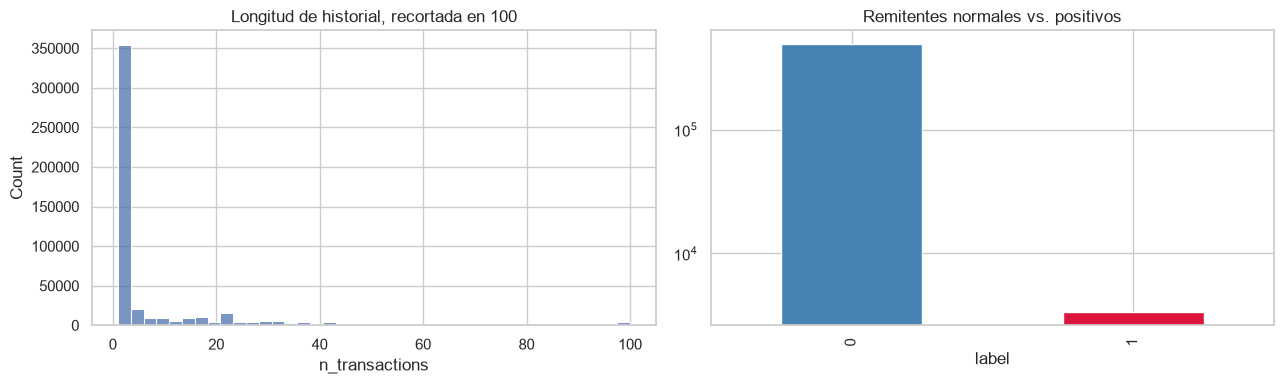

In [5]:
sender_audit = df.groupby('sender_id', observed=True).agg(
    n_transactions=('Is Laundering','size'),
    label=('Is Laundering','max')
)

display(sender_audit['n_transactions'].describe(percentiles=[.5,.75,.9,.95,.99]))
print()
print('Remitentes positivos:', int(sender_audit['label'].sum()))
print('Remitentes con 3 o más:', int((sender_audit['n_transactions'] >= 3).sum()))

fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(sender_audit['n_transactions'].clip(upper=100), bins=40, ax=axes[0])
axes[0].set_title('Longitud de historial, recortada en 100')
sender_audit['label'].value_counts().sort_index().plot.bar(ax=axes[1], color=['steelblue','crimson'])
axes[1].set_title('Remitentes normales vs. positivos'); axes[1].set_yscale('log')
plt.tight_layout(); plt.show()

## Bloque 3 — Split por remitente

El split se realiza antes de construir ventanas. Así, todas las transacciones de una misma cuenta quedan en un único conjunto y se evita filtración de comportamiento entre entrenamiento, validación y prueba.

In [6]:
eligible = sender_audit.query('n_transactions >= @CFG.MIN_SEQ_LEN').reset_index()

train_s, temp_s = train_test_split(
    eligible, test_size=0.30, random_state=CFG.SEED, stratify=eligible['label'])
val_s, test_s = train_test_split(
    temp_s, test_size=0.50, random_state=CFG.SEED, stratify=temp_s['label'])

split_map = {**dict(zip(train_s.sender_id, ['train']*len(train_s))),
             **dict(zip(val_s.sender_id, ['val']*len(val_s))),
             **dict(zip(test_s.sender_id, ['test']*len(test_s)))}

for name, part in [('train',train_s),('val',val_s),('test',test_s)]:
    print(name, f'remitentes={len(part):,}', f'positivos={int(part.label.sum()):,}',
          f'tasa={part.label.mean():.4%}')

assert set(train_s.sender_id).isdisjoint(val_s.sender_id)
assert set(train_s.sender_id).isdisjoint(test_s.sender_id)
assert set(val_s.sender_id).isdisjoint(test_s.sender_id)

train remitentes=130,195 positivos=1,931 tasa=1.4832%
val remitentes=27,899 positivos=414 tasa=1.4839%
test remitentes=27,899 positivos=413 tasa=1.4803%


### Análisis de la separación de datos

La separación se realizó a nivel de **remitente y antes de construir las ventanas temporales**. Esta decisión es fundamental para evitar filtración: todas las transacciones y todas las ventanas pertenecientes a un mismo remitente permanecen exclusivamente en entrenamiento, validación o prueba.

Se obtuvieron **130,195 remitentes de entrenamiento**, **27,899 de validación** y **27,899 de prueba**. Las tasas de remitentes positivos fueron respectivamente **1.4832 %, 1.4839 % y 1.4803 %**, mostrando que la estratificación conservó prácticamente la misma prevalencia en los tres conjuntos.

El conjunto de validación se utiliza para seleccionar umbrales, pesos de combinación y estados del modelo. El conjunto de prueba permanece fuera de estas decisiones y se utiliza únicamente para la evaluación final. Esto reduce el riesgo de obtener métricas optimistas debido a decisiones ajustadas indirectamente sobre test.

Se optó por una separación estratificada por remitente en lugar de una separación puramente temporal porque el objetivo principal de esta demostración es evaluar generalización hacia remitentes no observados. Una validación temporal constituiría un experimento adicional útil para estudiar deriva temporal, pero no sustituye la necesidad de impedir que un mismo remitente aparezca en varios splits.

## Bloque 4 — Features causales y secuencias

Las variables derivadas usan únicamente la transacción actual y el pasado del mismo remitente. Los identificadores de cuenta no entran al modelo: se conservan solo para trazabilidad.

Las ventanas tienen máximo 30 transacciones, aproximadamente el percentil 90 observado. Para impedir que cuentas gigantes dominen el experimento, se conservan como máximo 20 ventanas por remitente mediante selección uniforme e independiente de la etiqueta.

In [7]:
df = df[df['sender_id'].isin(split_map)].copy()
df['split'] = df['sender_id'].map(split_map)
df.sort_values(['sender_id','Timestamp'], inplace=True, kind='mergesort')
df.reset_index(drop=False, inplace=True)
df.rename(columns={'index':'original_row'}, inplace=True)

g = df.groupby('sender_id', observed=True, sort=False)
df['delta_minutes'] = g['Timestamp'].diff().dt.total_seconds().div(60).fillna(0).clip(lower=0)
df['sender_position'] = g.cumcount()
df['sender_count'] = g['sender_id'].transform('size')
df['position_ratio'] = df['sender_position'] / (df['sender_count']-1).clip(lower=1)
df['destination_changed'] = df['dest_id'].ne(g['dest_id'].shift()).astype('int8')
df.loc[df['sender_position'].eq(0), 'destination_changed'] = 0
df['new_destination'] = (~df.duplicated(['sender_id','dest_id'])).astype('int8')
df['same_bank'] = (df['From Bank'] == df['To Bank']).astype('int8')
df['same_account'] = (df['sender_id'] == df['dest_id']).astype('int8')
df['currency_changed'] = (df['Payment Currency'].astype(str) != df['Receiving Currency'].astype(str)).astype('int8')
df['log_amount_paid'] = np.log1p(df['Amount Paid'].clip(lower=0))
df['log_amount_received'] = np.log1p(df['Amount Received'].clip(lower=0))
df['log_amount_gap'] = np.log1p((df['Amount Paid']-df['Amount Received']).abs())
df['log_fx_ratio'] = np.log((df['Amount Received']+1e-6)/(df['Amount Paid']+1e-6)).clip(-10,10)
df['log_delta_minutes'] = np.log1p(df['delta_minutes'])
df['log_tx_count_so_far'] = np.log1p(df['sender_position']+1)
df['hour_sin'] = np.sin(2*np.pi*df['Timestamp'].dt.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df['Timestamp'].dt.hour/24)
df['day_offset'] = (df['Timestamp']-df['Timestamp'].min()).dt.total_seconds()/86400

CONT_COLS = ['log_amount_paid','log_amount_received','log_amount_gap','log_fx_ratio',
             'log_delta_minutes','log_tx_count_so_far','hour_sin','hour_cos',
             'day_offset','position_ratio','same_bank','same_account',
             'currency_changed','destination_changed','new_destination']
CAT_COLS = ['Payment Currency','Receiving Currency','Payment Format']

def make_windows(frame):
    records = []
    labels = frame['Is Laundering'].to_numpy()
    splits = frame['split'].to_numpy()
    for sender, part in frame.groupby('sender_id', observed=True, sort=False):
        start0, n = part.index[0], len(part)
        candidate = []
        for offset in range(0, n, CFG.MAX_SEQ_LEN):
            end = min(offset + CFG.MAX_SEQ_LEN, n)
            if end-offset >= CFG.MIN_SEQ_LEN:
                s, e = start0+offset, start0+end
                candidate.append((s,e))
        if len(candidate) > CFG.MAX_WINDOWS_PER_SENDER:
            chosen = np.linspace(0, len(candidate)-1, CFG.MAX_WINDOWS_PER_SENDER).round().astype(int)
            candidate = [candidate[i] for i in np.unique(chosen)]
        for s,e in candidate:
            records.append({
                'sender_id': sender, 'split': splits[s], 'start':s, 'end':e,
                'length':e-s, 'label':int(labels[s:e].max())
            })
    return pd.DataFrame(records)

windows = make_windows(df)
display(windows.groupby('split').agg(windows=('label','size'), positives=('label','sum'),
                                     rate=('label','mean'), mean_length=('length','mean')))
assert windows['length'].between(CFG.MIN_SEQ_LEN, CFG.MAX_SEQ_LEN).all()

,windows,positives,rate,mean_length
split,,,,
test,37778,424,0.011223,16.783260
train,174659,1953,0.011182,16.662147
val,37162,419,0.011275,16.549055


### Justificación de la representación secuencial

Cada secuencia representa un fragmento cronológicamente ordenado del comportamiento de un único remitente. Se utiliza una longitud mínima de **3 transacciones**, ya que historiales más cortos ofrecen muy poca información temporal para caracterizar cambios de frecuencia, destino o comportamiento. La longitud máxima se fija en **30 transacciones**, aproximadamente el percentil 90 de longitud observado en HI-Small. Los historiales más largos se dividen en ventanas y se limita el número de ventanas por remitente para evitar que unas pocas cuentas extremadamente activas dominen el entrenamiento.

Las variables fueron seleccionadas para representar diferentes dimensiones del comportamiento transaccional:

- Los montos transformados mediante `log1p` reducen el efecto de distribuciones fuertemente asimétricas y permiten representar diferencias relativas entre operaciones pequeñas y grandes.
- `delta_minutes` y el conteo acumulado representan **frecuencia y velocidad transaccional**, relevantes para detectar incrementos abruptos de actividad.
- Las variables de hora mediante seno y coseno conservan la naturaleza cíclica del tiempo y permiten representar actividad en horarios inusuales.
- `destination_changed` y `new_destination` capturan cambios de contraparte y aparición de nuevos destinos, comportamientos potencialmente relevantes para patrones de dispersión.
- `same_bank`, `same_account` y `currency_changed` describen características estructurales de la transferencia.
- La diferencia entre montos enviados y recibidos y el ratio asociado permiten representar transformaciones de valor y moneda.
- Las variables categóricas de moneda y formato de pago se codifican mediante one-hot encoding.

Todas las variables derivadas utilizan únicamente información disponible en la transacción actual o en el pasado del remitente. No se utiliza la etiqueta para construir features. El escalador y el codificador categórico se ajustan exclusivamente con datos de entrenamiento.

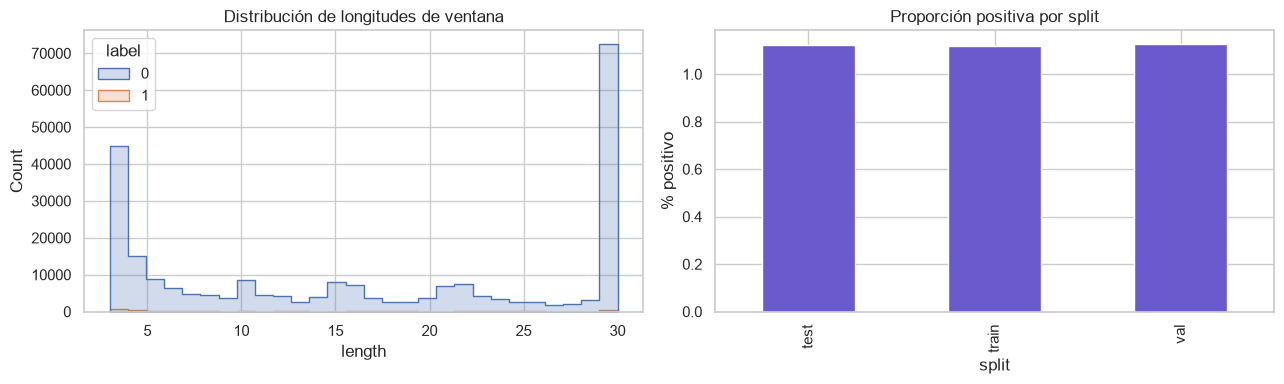

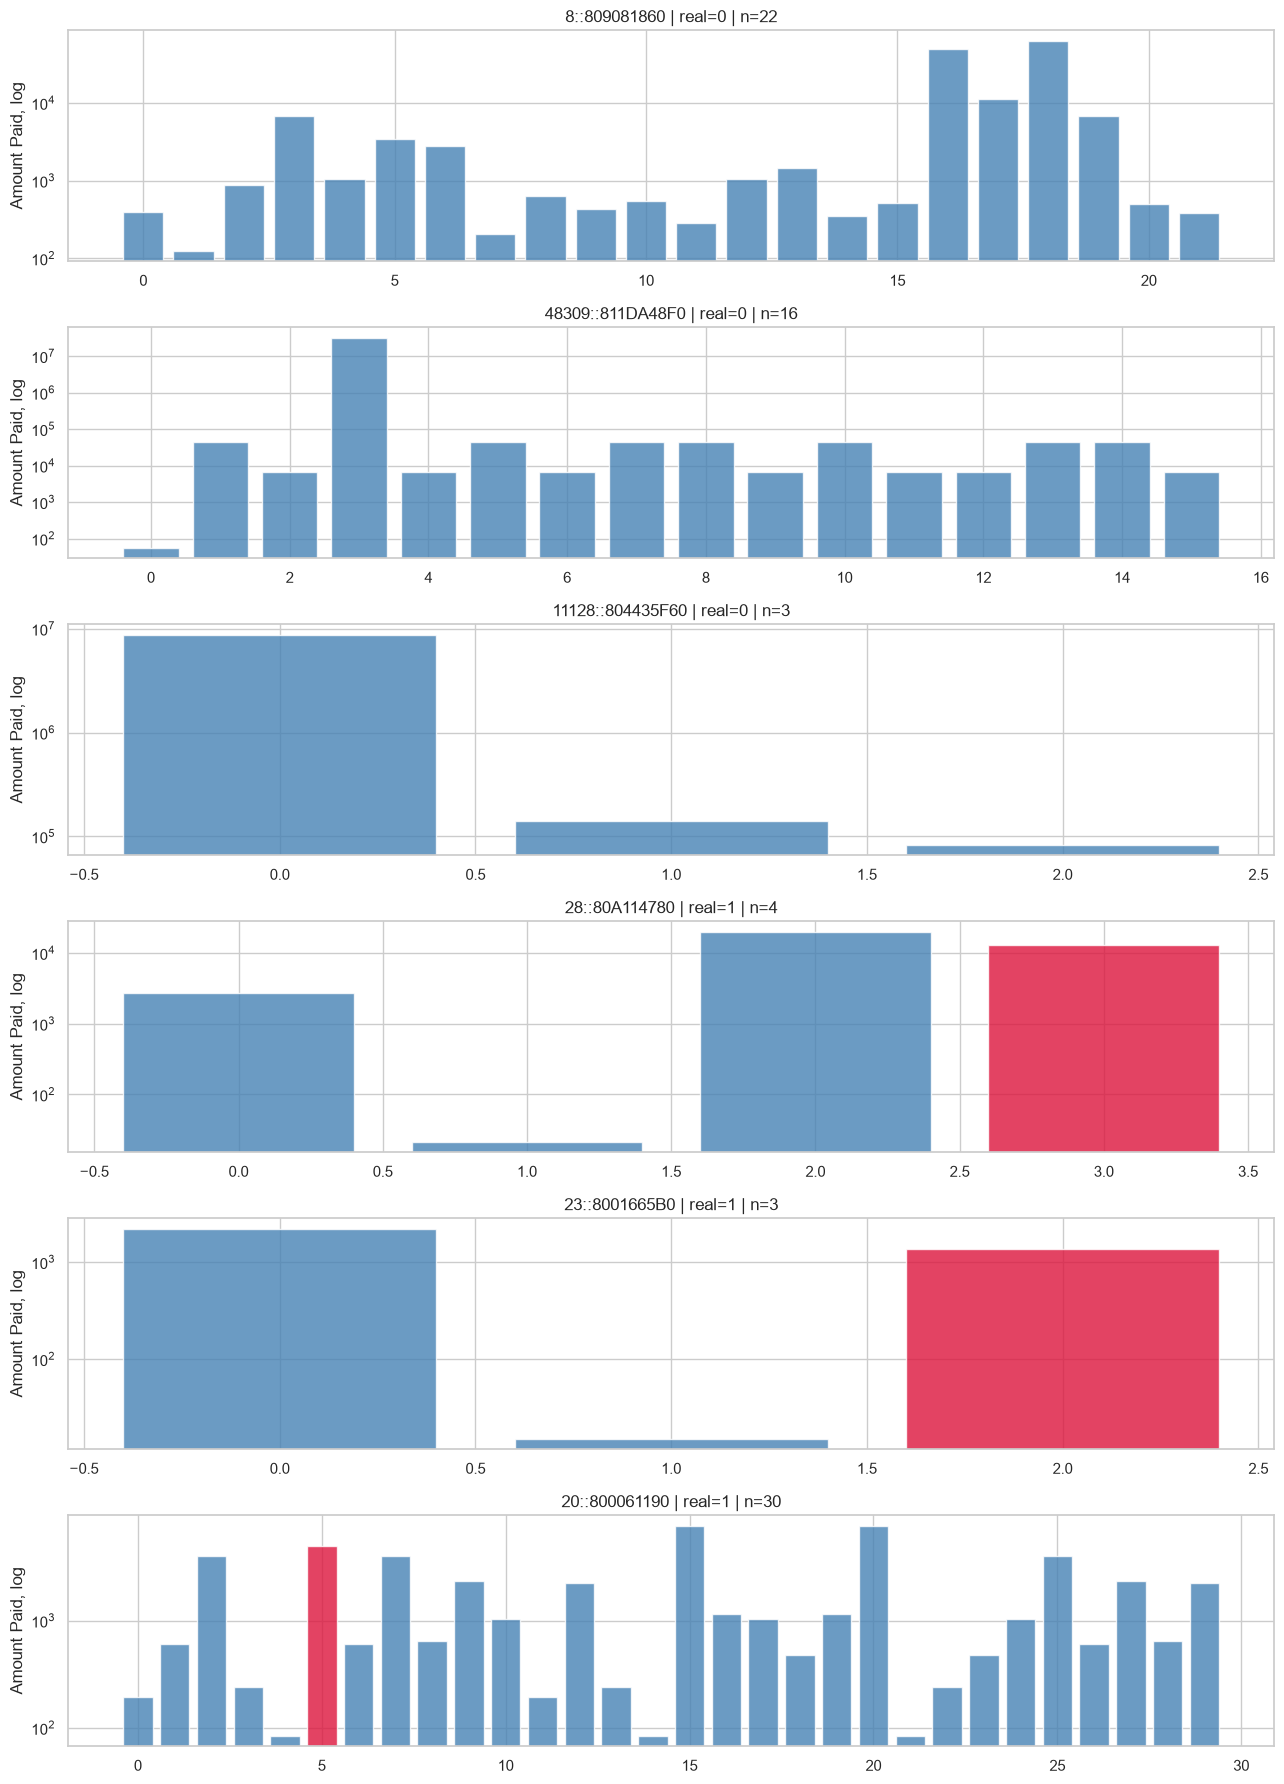

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13,4))
sns.histplot(data=windows, x='length', hue='label', bins=28, element='step', ax=axes[0])
axes[0].set_title('Distribución de longitudes de ventana')
windows.groupby('split')['label'].mean().mul(100).plot.bar(ax=axes[1], color='slateblue')
axes[1].set_ylabel('% positivo'); axes[1].set_title('Proporción positiva por split')
plt.tight_layout(); plt.show()

def plot_sequence_examples(frame, meta, n_each=3):
    selected = pd.concat([
        meta.query('split == "train" and label == 0').sample(n_each, random_state=CFG.SEED),
        meta.query('split == "train" and label == 1').sample(n_each, random_state=CFG.SEED)
    ])
    fig, axes = plt.subplots(len(selected), 1, figsize=(13, 3*len(selected)), squeeze=False)
    for ax, (_, w) in zip(axes[:,0], selected.iterrows()):
        p = frame.iloc[int(w.start):int(w.end)]
        colors = np.where(p['Is Laundering'].to_numpy()==1, 'crimson', 'steelblue')
        ax.bar(range(len(p)), p['Amount Paid'], color=colors, alpha=.8)
        ax.set_yscale('log'); ax.set_ylabel('Amount Paid, log')
        ax.set_title(f"{w.sender_id} | real={w.label} | n={w.length}")
    plt.tight_layout(); plt.show()

plot_sequence_examples(df, windows, n_each=3)

## Bloque 5 — Preprocesamiento sin filtración

El escalador y el one-hot encoder se ajustan exclusivamente con filas pertenecientes a ventanas de entrenamiento. Después se transforman validación y prueba con los mismos parámetros.

In [9]:
def select_training_windows(meta):
    train = meta.query('split == "train"')
    pos = train.query('label == 1')
    neg = train.query('label == 0')
    max_neg = min(len(neg), max(CFG.MAX_NORMAL_AE, CFG.NORMAL_TO_POSITIVE_B*max(len(pos),1)))
    neg = neg.sample(max_neg, random_state=CFG.SEED)
    return pd.concat([pos,neg]).sample(frac=1, random_state=CFG.SEED).reset_index(drop=True)

train_windows = select_training_windows(windows)
val_windows = windows.query('split == "val"').reset_index(drop=True)
test_windows = windows.query('split == "test"').reset_index(drop=True)
selected_windows = pd.concat([train_windows,val_windows,test_windows], ignore_index=True)

used = np.zeros(len(df), dtype=bool)
for w in selected_windows.itertuples(): used[w.start:w.end] = True
old_to_new = np.full(len(df), -1, dtype=np.int64)
old_to_new[np.flatnonzero(used)] = np.arange(used.sum())
compact = df.loc[used].copy().reset_index(drop=True)

for meta in (train_windows,val_windows,test_windows):
    meta['start_compact'] = meta['start'].map(lambda x: int(old_to_new[int(x)]))
    meta['end_compact'] = meta['end'].map(lambda x: int(old_to_new[int(x)-1])+1)

try:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float32)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', sparse=False, dtype=np.float32)

preprocessor = ColumnTransformer([
    ('continuous', StandardScaler(), CONT_COLS),
    ('categorical', ohe, CAT_COLS)
], remainder='drop', verbose_feature_names_out=False)

train_row_mask = compact['split'].eq('train')
preprocessor.fit(compact.loc[train_row_mask, CONT_COLS+CAT_COLS])
X_all = preprocessor.transform(compact[CONT_COLS+CAT_COLS]).astype('float32')
FEATURE_NAMES = list(preprocessor.get_feature_names_out())

print('Filas utilizadas:', f'{len(compact):,}', '| Features:', X_all.shape[1])
print(FEATURE_NAMES)
assert np.isfinite(X_all).all()

Filas utilizadas: 2,270,514 | Features: 52
['log_amount_paid', 'log_amount_received', 'log_amount_gap', 'log_fx_ratio', 'log_delta_minutes', 'log_tx_count_so_far', 'hour_sin', 'hour_cos', 'day_offset', 'position_ratio', 'same_bank', 'same_account', 'currency_changed', 'destination_changed', 'new_destination', 'Payment Currency_Australian Dollar', 'Payment Currency_Bitcoin', 'Payment Currency_Brazil Real', 'Payment Currency_Canadian Dollar', 'Payment Currency_Euro', 'Payment Currency_Mexican Peso', 'Payment Currency_Ruble', 'Payment Currency_Rupee', 'Payment Currency_Saudi Riyal', 'Payment Currency_Shekel', 'Payment Currency_Swiss Franc', 'Payment Currency_UK Pound', 'Payment Currency_US Dollar', 'Payment Currency_Yen', 'Payment Currency_Yuan', 'Receiving Currency_Australian Dollar', 'Receiving Currency_Bitcoin', 'Receiving Currency_Brazil Real', 'Receiving Currency_Canadian Dollar', 'Receiving Currency_Euro', 'Receiving Currency_Mexican Peso', 'Receiving Currency_Ruble', 'Receiving Cur